In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/train.csv')
df.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


# EXPLORATORY DATA ANALYSIS (EDA)
## Analysis of Student Dropout/Graduate/Enrolled Data
### Step 1: Variable Classification

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset shape: (76518, 38)

Column names:
['id', 'Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 

In [4]:
categorical_vars = [
    'Marital status',
    'Application mode', 
    'Application order',
    'Course',
    'Daytime/evening attendance',
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
    'Target'
]

numerical_vars = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
    'Admission grade',
    'Previous qualification (grade)'
]

print(f"Number of categorical variables: {len(categorical_vars)}")
print(f"Number of numerical variables: {len(numerical_vars)}")

Number of categorical variables: 19
Number of numerical variables: 18


### Step 2: Correlation Analysis
Draw a Correlation Heatmap to identify pairs of variables with high correlation (> 0.9)

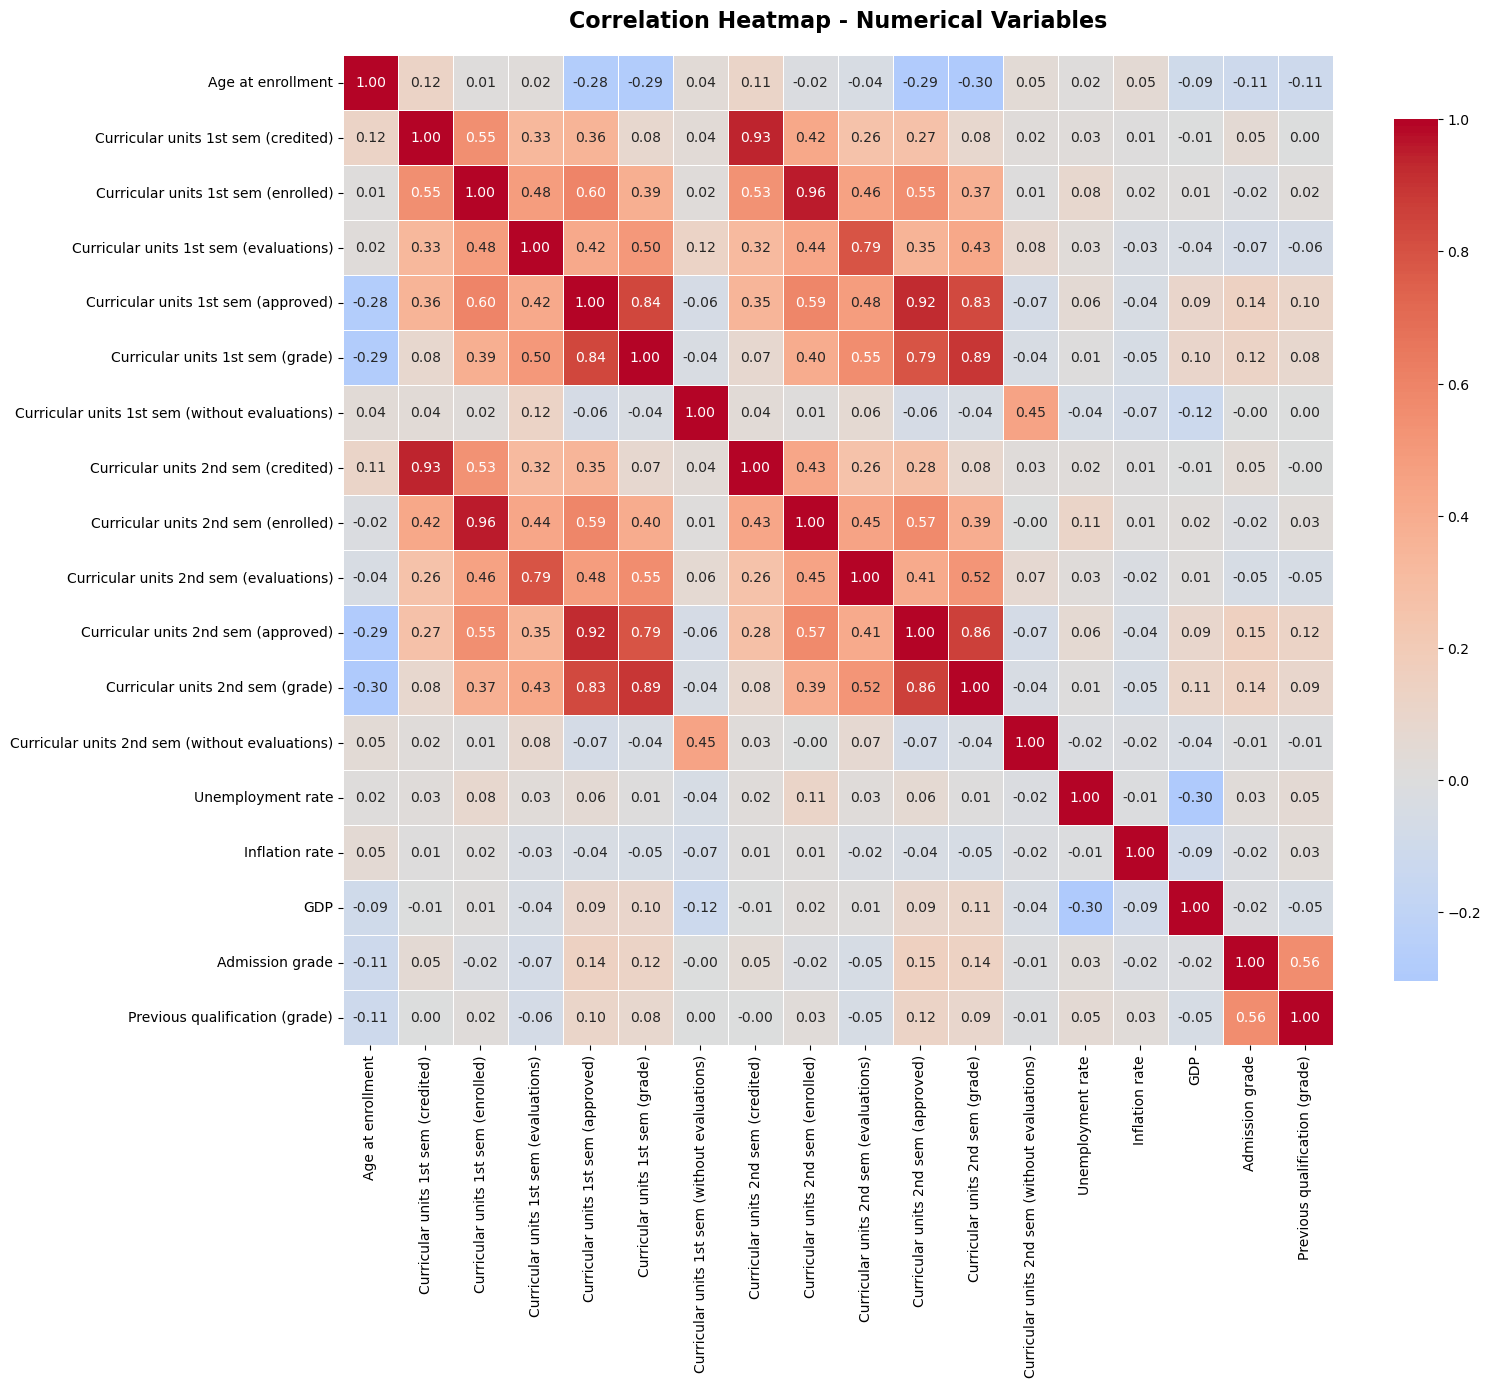


PAIRS OF VARIABLES WITH HIGH CORRELATION (|r| > 0.9):
• Curricular units 1st sem (credited) <-> Curricular units 2nd sem (credited) : 0.934
• Curricular units 1st sem (enrolled) <-> Curricular units 2nd sem (enrolled) : 0.956
• Curricular units 1st sem (approved) <-> Curricular units 2nd sem (approved) : 0.923


In [5]:
correlation_matrix = df[numerical_vars].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find pairs of variables with high correlation (>0.9)
print("\nPAIRS OF VARIABLES WITH HIGH CORRELATION (|r| > 0.9):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            corr_val = correlation_matrix.iloc[i, j]
            high_corr_pairs.append((var1, var2, corr_val))
            print(f"• {var1[:50]:20s} <-> {var2[:50]:20s} : {corr_val:.3f}")

if len(high_corr_pairs) == 0:
    print("There are no variable pairs with a correlation greater than 0.9")

### Step 3: Identify Important Variables affecting the Target
Analyze the relationships between the variables and the target (Dropout / Enrolled / Graduate)

In [6]:
print("Target distribution:")
print(df['Target'].value_counts())

Target distribution:
Target
Graduate    36282
Dropout     25296
Enrolled    14940
Name: count, dtype: int64


#### 3.1. Boxplot for Quantitative Variables vs Target

C:\Users\PHUC\AppData\Local\Temp\ipykernel_13896\182892437.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=var, ax=axes[idx], palette='Set2')
C:\Users\PHUC\AppData\Local\Temp\ipykernel_13896\182892437.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=var, ax=axes[idx], palette='Set2')
C:\Users\PHUC\AppData\Local\Temp\ipykernel_13896\182892437.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=var, ax=axes[idx], palette='Set2')
C:\Users\PHUC\AppData\Local\Temp\ipyk

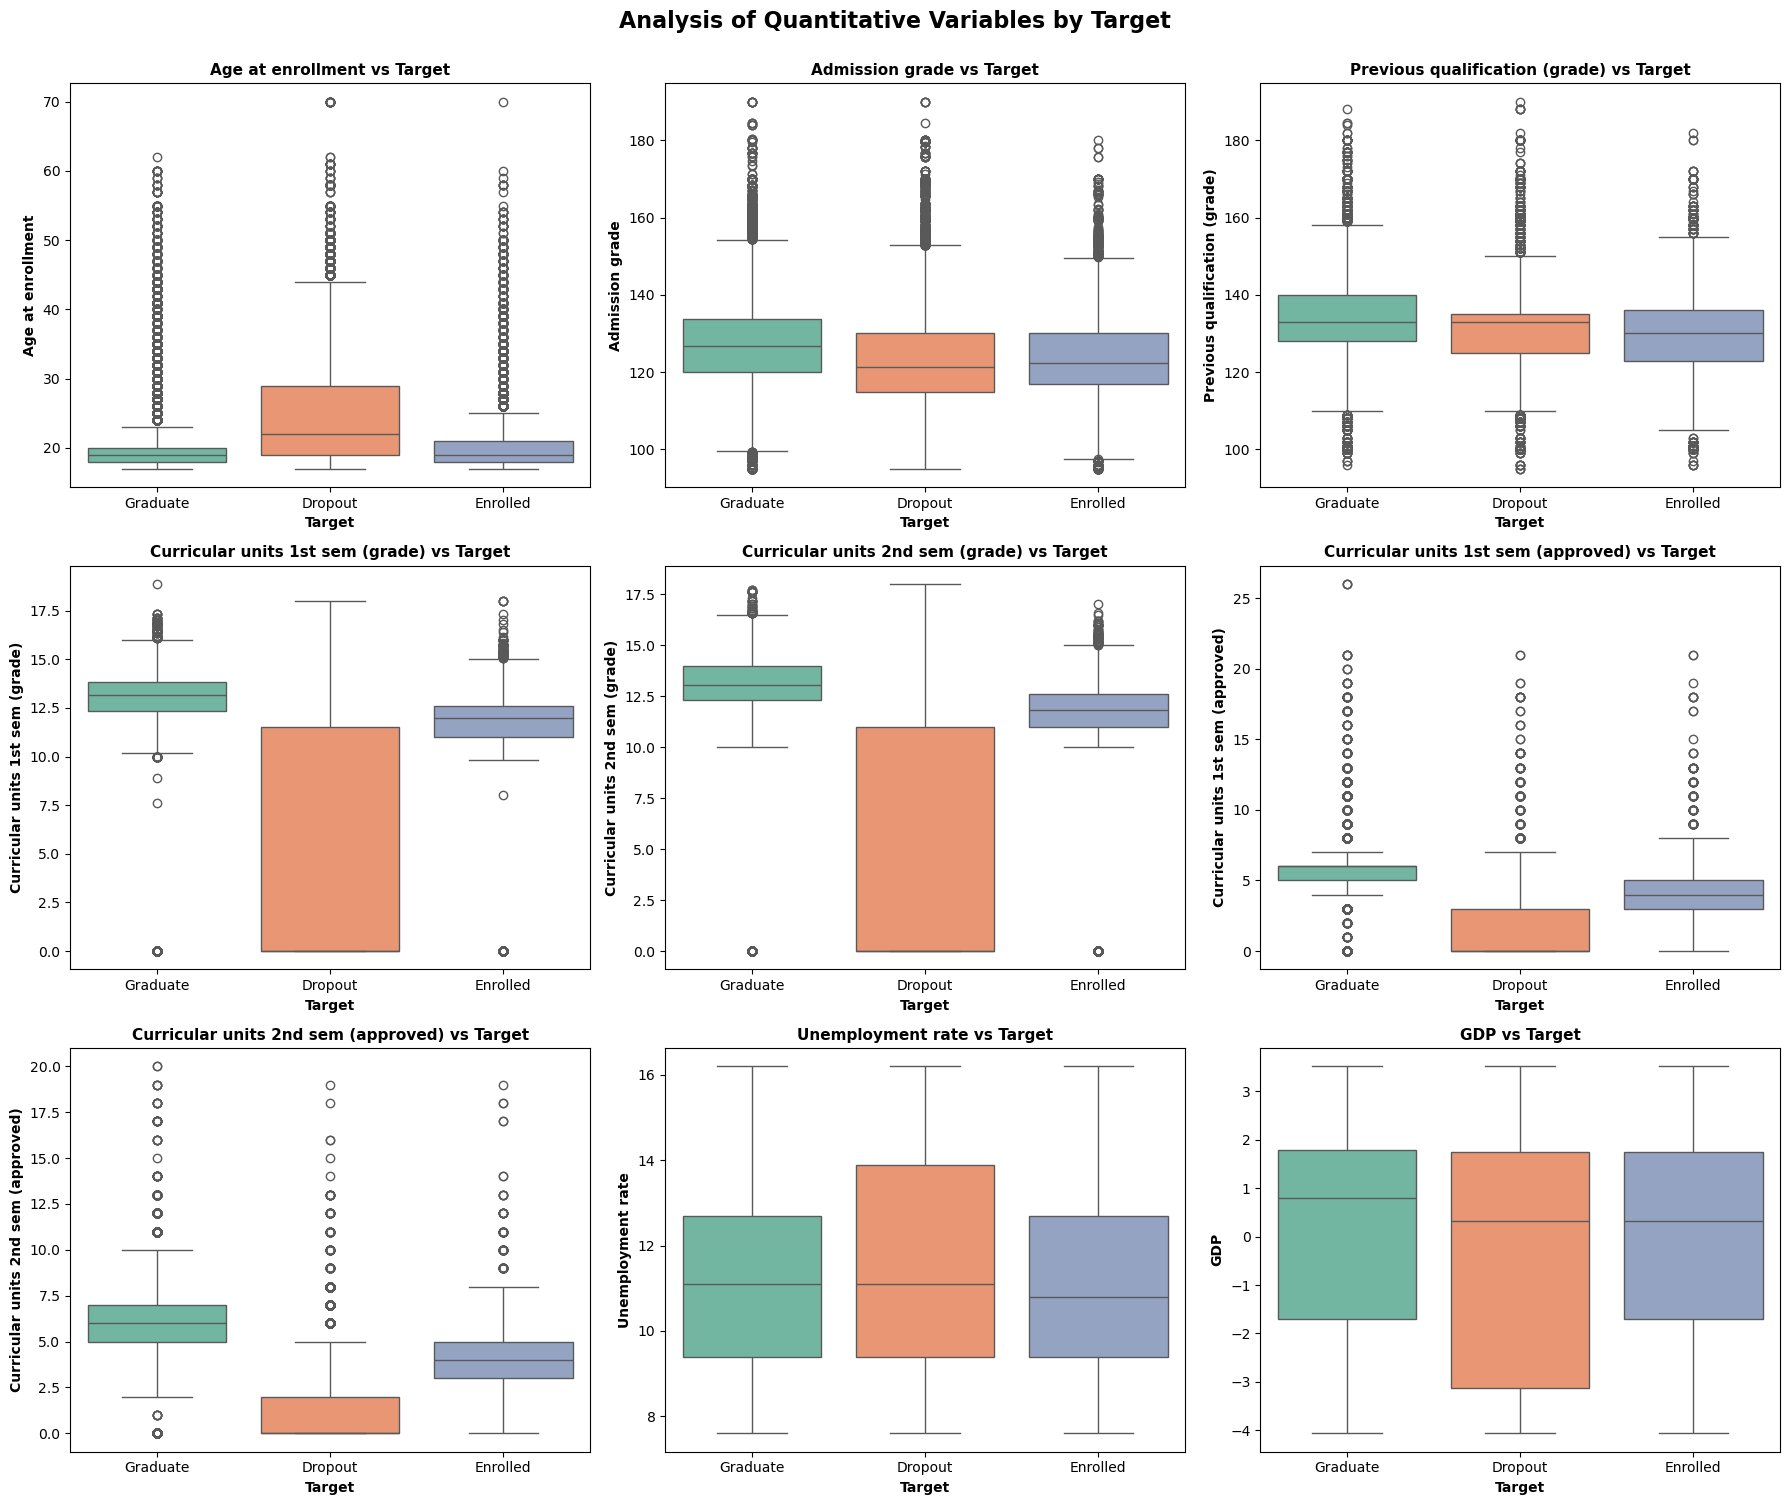

In [7]:
important_numerical = [
    'Age at enrollment',
    'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Unemployment rate',
    'GDP'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, var in enumerate(important_numerical):
    sns.boxplot(data=df, x='Target', y=var, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{var} vs Target', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Target', fontweight='bold')
    axes[idx].set_ylabel(var, fontweight='bold')
    axes[idx].tick_params(axis='x')

plt.suptitle('Analysis of Quantitative Variables by Target', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

#### 3.2. Stacked Bar Chart for Categorical Variables vs Target

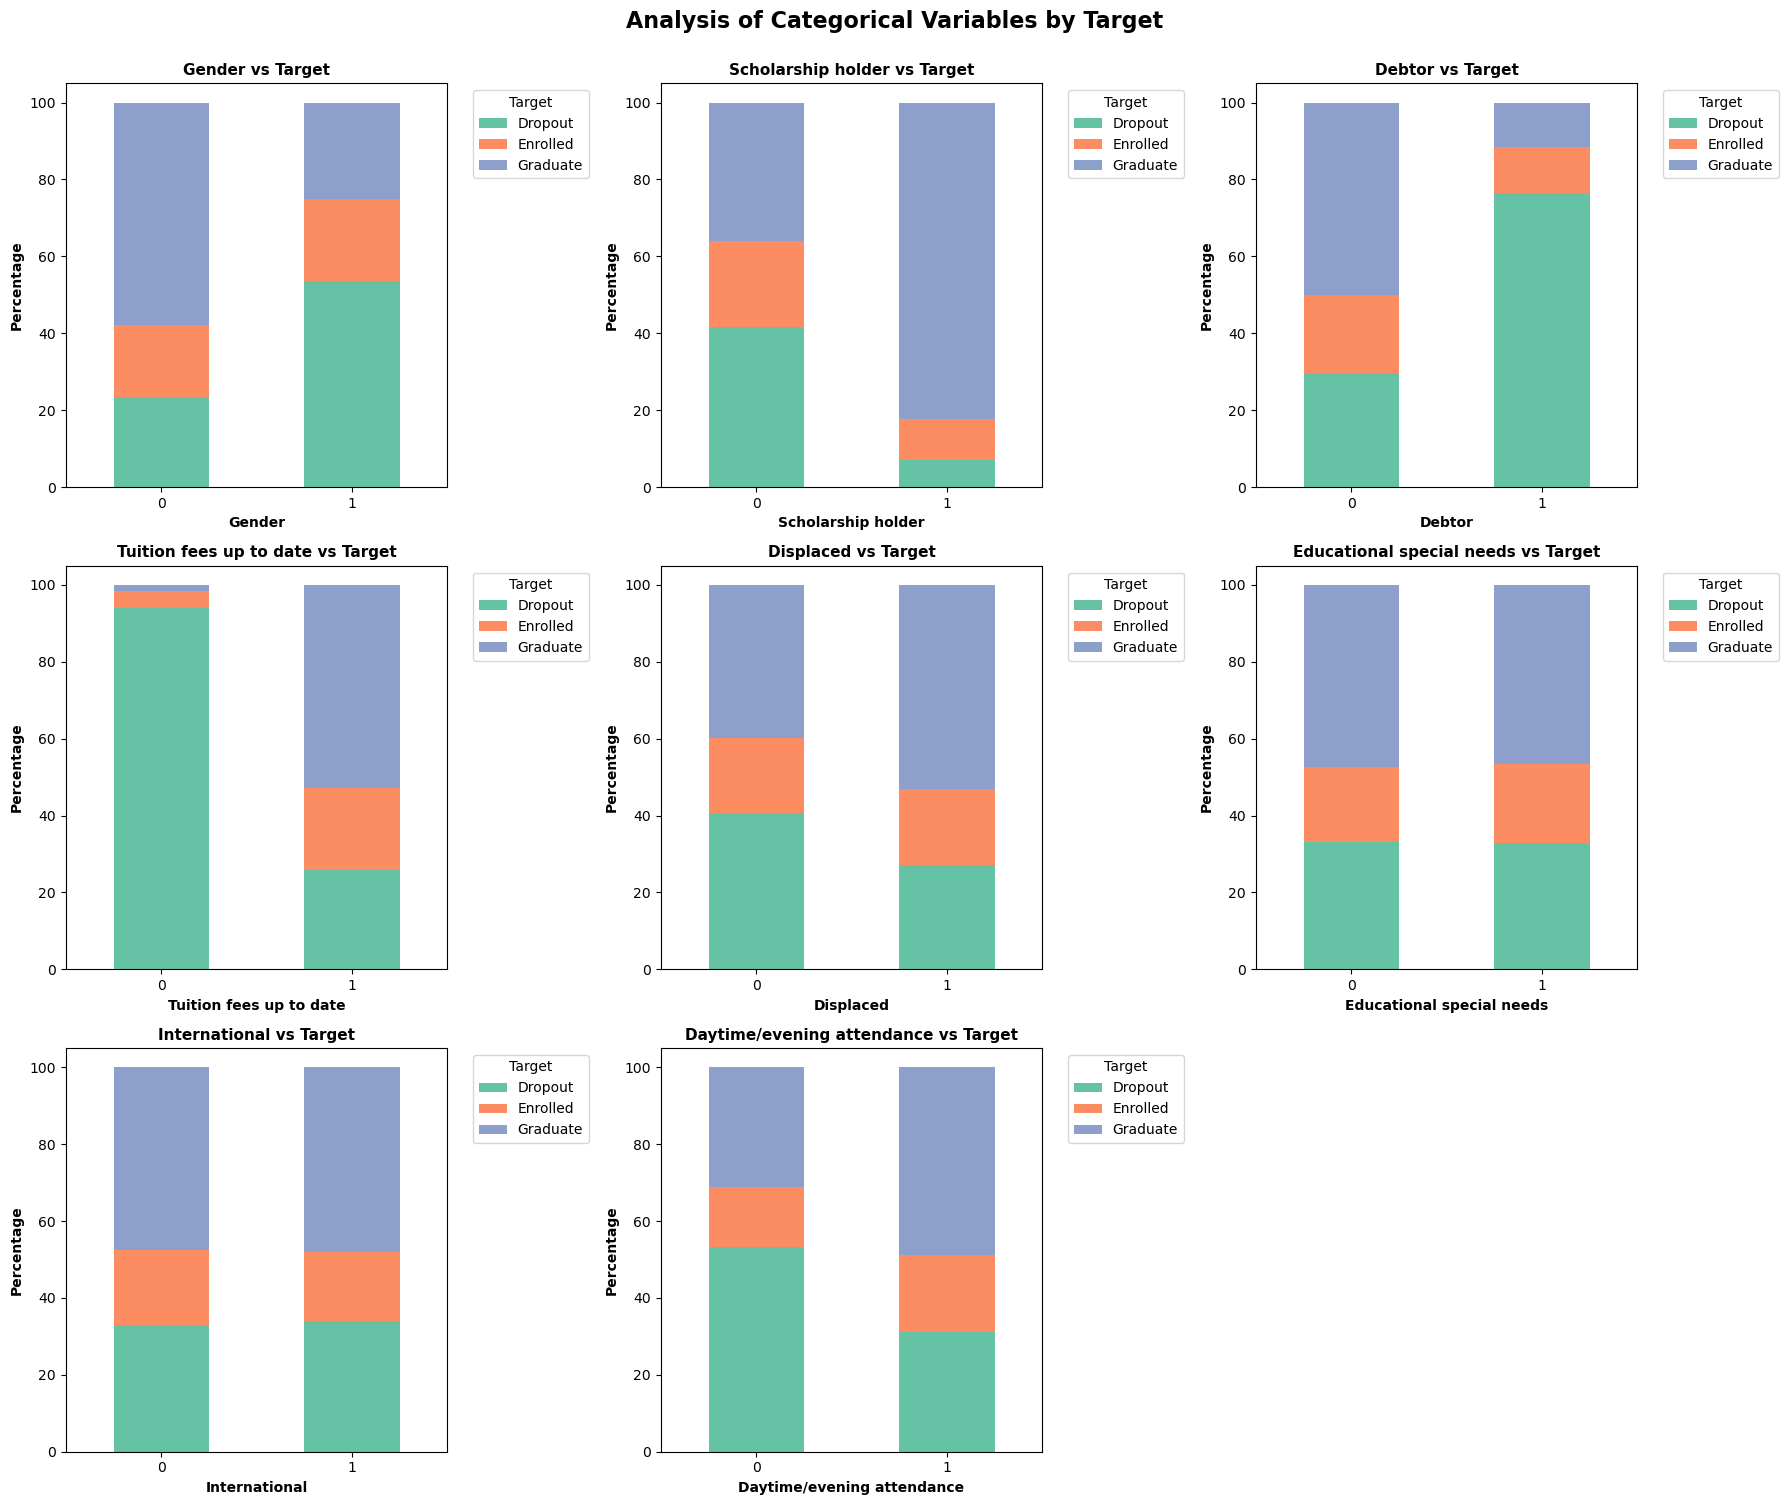

In [8]:
important_categorical = [
    'Gender',
    'Scholarship holder',
    'Debtor',
    'Tuition fees up to date',
    'Displaced',
    'Educational special needs',
    'International',
    'Daytime/evening attendance'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, var in enumerate(important_categorical):
    ct = pd.crosstab(df[var], df['Target'], normalize='index') * 100
    
    ct.plot(kind='bar', stacked=True, ax=axes[idx], 
            color=['#66c2a5', '#fc8d62', '#8da0cb'])
    
    axes[idx].set_title(f'{var} vs Target', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel(var, fontweight='bold')
    axes[idx].set_ylabel('Percentage', fontweight='bold')
    axes[idx].legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[idx].tick_params(axis='x', rotation=0)

axes[-1].axis('off')

plt.suptitle('Analysis of Categorical Variables by Target', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Step 4: Analyze the relationship between Important Variable Pairs (Scatter Plot)

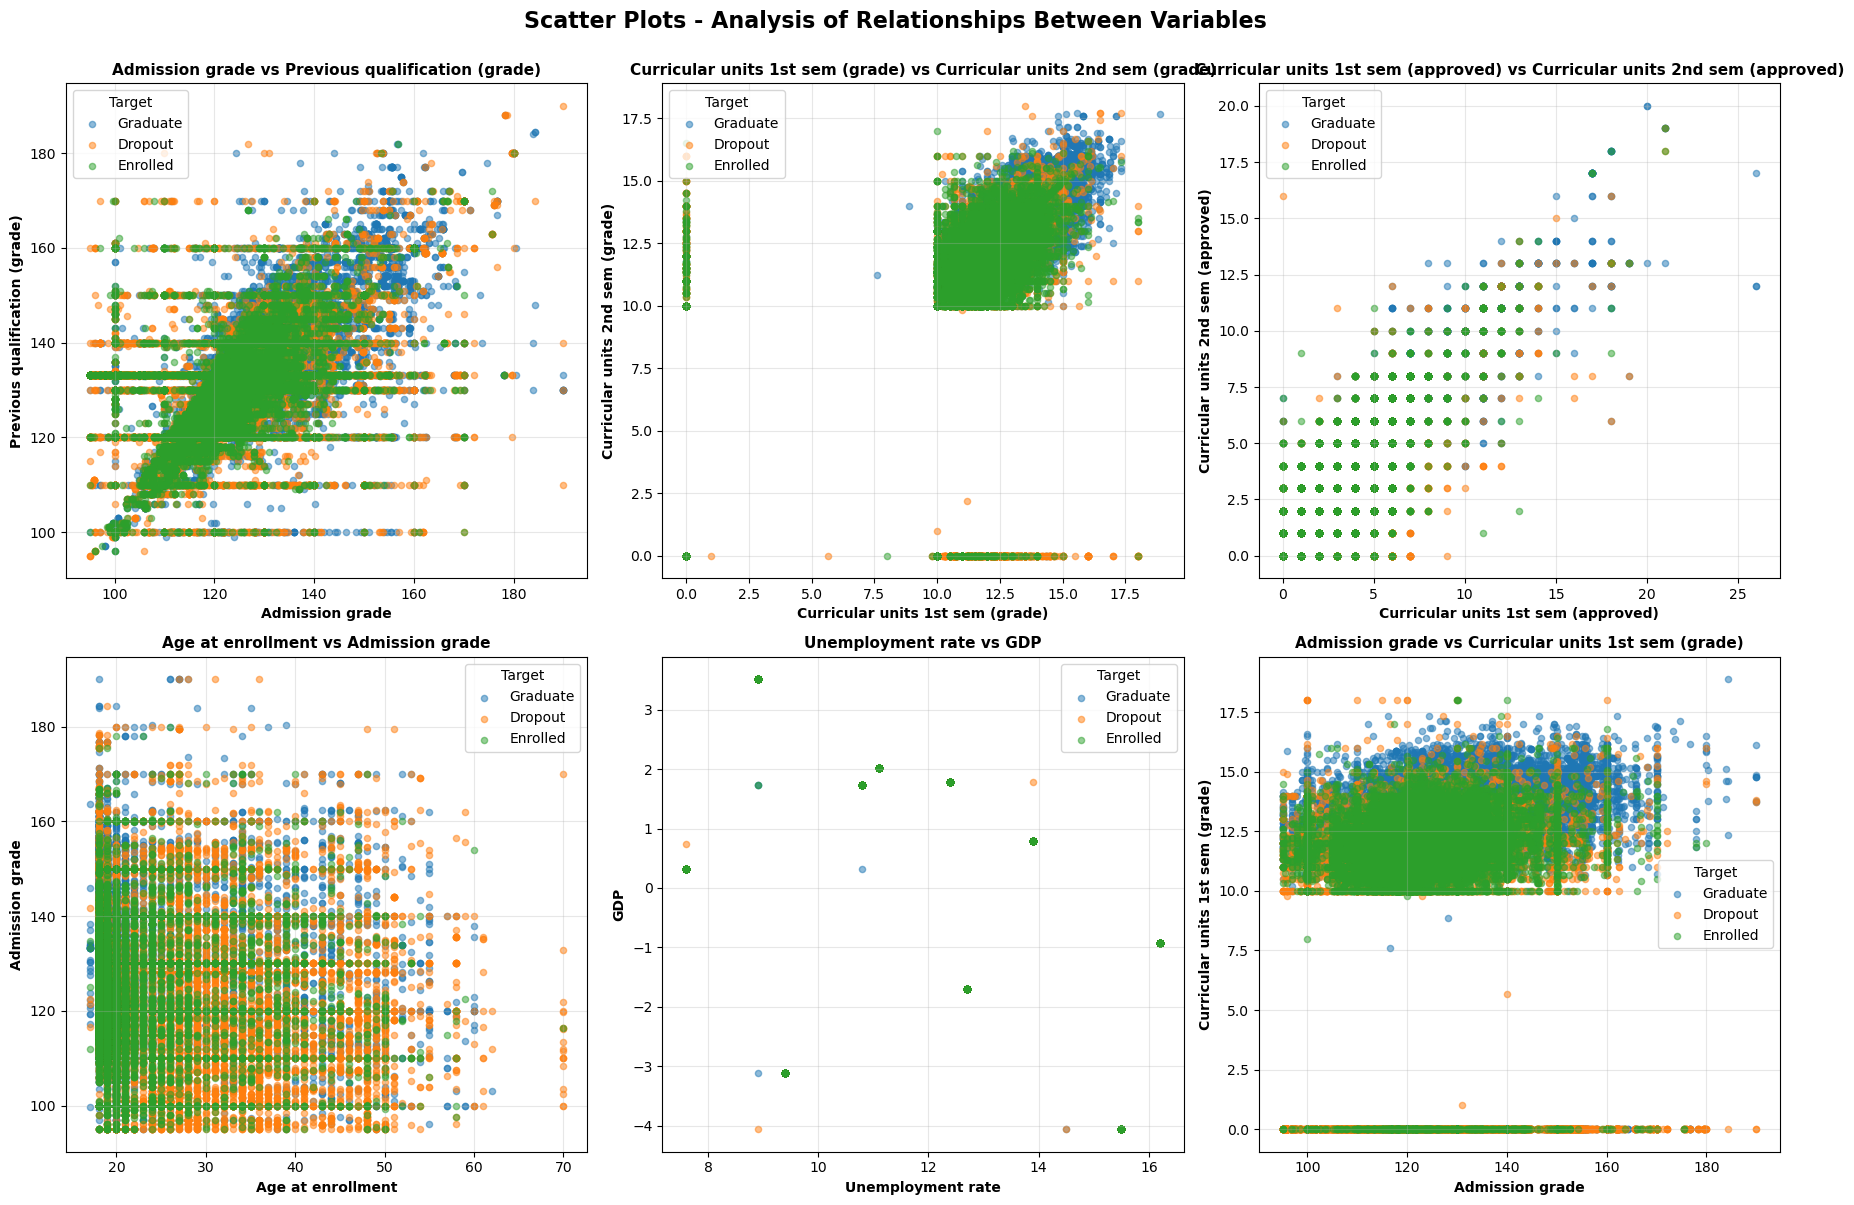

In [9]:
scatter_pairs = [
    ('Admission grade', 'Previous qualification (grade)'),
    ('Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'),
    ('Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)'),
    ('Age at enrollment', 'Admission grade'),
    ('Unemployment rate', 'GDP'),
    ('Admission grade', 'Curricular units 1st sem (grade)')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (var1, var2) in enumerate(scatter_pairs):
    for target in df['Target'].unique():
        mask = df['Target'] == target
        axes[idx].scatter(df[mask][var1], df[mask][var2], 
                         alpha=0.5, s=20, label=target)
    
    axes[idx].set_xlabel(var1, fontweight='bold')
    axes[idx].set_ylabel(var2, fontweight='bold')
    axes[idx].set_title(f'{var1} vs {var2}', fontweight='bold', fontsize=11)
    axes[idx].legend(title='Target')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Scatter Plots - Analysis of Relationships Between Variables', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Step 5: Record Insights

### 1. Variable Classification
- **Total number of variables**: 38 variables (including the Target)
- **Quantitative variables**: 18 variables (Age, Grades, GDP, Unemployment rate, etc.)
- **Categorical variables**: 19 variables (Gender, Scholarship, Debtor, Course, etc.)
---

### 2. Correlation Analysis
#### Pairs of variables with high correlation (|r| > 0.9):
1. **Curricular units 1st sem (credited) ↔ 2nd sem (credited)**: r = 0.934
2. **Curricular units 1st sem (enrolled) ↔ 2nd sem (enrolled)**: r = 0.956
3. **Curricular units 1st sem (approved) ↔ 2nd sem (approved)**: r = 0.923

**Insight**: 
- Scores and number of subjects in semester 1 and semester 2 have extremely strong correlations
- One of the two variables (semester 1 or semester 2) can be removed to reduce multicollinearity in the model
- Students tend to maintain a similar level of academic performance across semesters
---

### 3. Analysis of Importance Variables affecting the Target
#### A. Numerical Variables
**Grades**
- **Curricular units 1st/2nd sem (grade)**: 
  - The **Graduate** group has the highest average scores (~13–14)
  - The **Dropout** group has very low scores, with many cases = 0 (did not take the exam/skipped exams)
  - The **Enrolled** group is at an average level (~12)
  - **Insight**: Scores are the strongest predictor of dropping out

**Age at enrollment**
- **Dropout** students tend to be older (median ~23–25)
- **Graduate** students are usually younger (median ~20)
- **Insight**: Late-enrolling students have a higher risk of dropping out

**Admission grade & Previous qualification (grade)**
- The **Graduate** group has higher admission and previous grades
- The **Dropout** group shows a wider grade distribution, with many low outliers
- **Insight**: A strong academic background increases the likelihood of graduation

**Number of Approved Courses (1st/2nd Semester)**
- **Graduate**: Average ~5–6 courses passed per semester
- **Dropout**: Many students pass 0 or very few courses
- **Insight**: Number of courses passed is an early warning indicator of potential dropout

**GDP & Unemployment rate**
- Slight differences exist between groups, but not clearly defined
- Further analysis is needed to determine the actual impact
---

#### B. Categorical Variables
**Scholarship holder**
- Students **WITHOUT a scholarship** (0): ~40% Dropout, ~33% Enrolled
- Students **WITH a scholarship** (1): Only ~10% Dropout, ~80% Graduate
- **IMPORTANT INSIGHT**: Scholarships significantly reduce the dropout rate

**Debtor**
- Students **WITHOUT debt** (0): ~50% Graduate, ~25% Dropout
- Students **WITH debt** (1): ~75% Dropout, very few Graduate
- **IMPORTANT INSIGHT**: Tuition debt is a very high-risk factor for dropout

**Tuition fees up to date**
- Similar to Debtor, students who have not updated their tuition fees have a very high dropout rate
- **Insight**: Financial issues are a major barrier

**Gender**
- Male (0): Higher Dropout rate (~25%)
- Female (1): Higher Graduate rate (~55%), lower Dropout rate
- **Insight**: Female students tend to complete the program more successfully

**Displaced**
- Displaced students have a significantly higher Dropout rate
- **Insight**: Stability in living conditions affects academic performance

**Daytime/evening attendance**
- Daytime students have higher graduation rates
- Evening students may need to work => higher risk of dropout

**International**
- International and local students have relatively similar rates
- No major differences observed
---

### 4. Analyze the relationship between Important Variable Pairs (Scatter Plots)
**1. Admission grade vs Previous qualification (grade)**
- Weak-to-moderate positive correlation
- Many scores are concentrated at standard values (100, 120, 140, 160)
- The Dropout group is more widely dispersed

**2. Curricular units 1st sem (grade) vs 2nd sem (grade)**
- Strong positive correlation
- Dropout students cluster around (0,0) - no grades in either semester
- Graduate students cluster in the high-score region (13–16)

**3. Curricular units 1st/2nd sem (approved)**
- Clear linear relationship
- Clustering by Target is very distinct
- Dropout students are near the axis (0,0)

**4. Age at enrollment vs Admission grade**
- No clear linear relationship
- Ages are widely dispersed, but Dropout students tend to be older

**5. Unemployment rate vs GDP**
- Slight negative correlation (higher unemployment corresponds to lower GDP)
- No clear pattern according to Target
---
## Conclusion
### High-Risk Factors for DROPOUT:
1. Low scores (especially in semesters 1 and 2)
2. Tuition debt or unpaid tuition
3. No scholarship
4. Older age at enrollment
5. Low number of approved courses
6. Displacement
7. Evening attendance

### Positive Factors for GRADUATE:
1. Has a scholarship
2. High scores during semesters
3. Younger age at enrollment
4. Strong academic background (high previous qualification grade)
5. No tuition debt
6. Female gender

### Recommendations for Data Preparation:
1. Handle multicollinearity: Consider removing one of the two variables between semester 1 and semester 2
2. Feature Engineering:
    - Create aggregate features (e.g., ratio of passed courses / registered courses)
    - Create interaction features (e.g., Scholarship × Debtor)
3. Handle zero values: Many Dropout students have scores = 0 => distinguish between "true 0" vs "missing"
4. Balance the dataset: Target is imbalanced (Graduate > Dropout > Enrolled)
5. Encoding: Categorical variables need proper encoding (One-hot, Label encoding)